In [1]:
import sys
import os
# get to project root
os.chdir('..')
print(os.getcwd())

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json


--- Calculating Robust Scaling Threshold ---
p*_th (Scaling): 0.0045383 ± 0.0000332
c = 1.22000
alpha = 0.70137 +/- 0.00078

--- Calculating Robust Cross Threshold ---
Using 6 data points for cross-threshold fit...
p^x_th (Cross): 0.0031768 ± 0.0001053
v_0 (Crit Exp): 1.20919 ± 0.21473


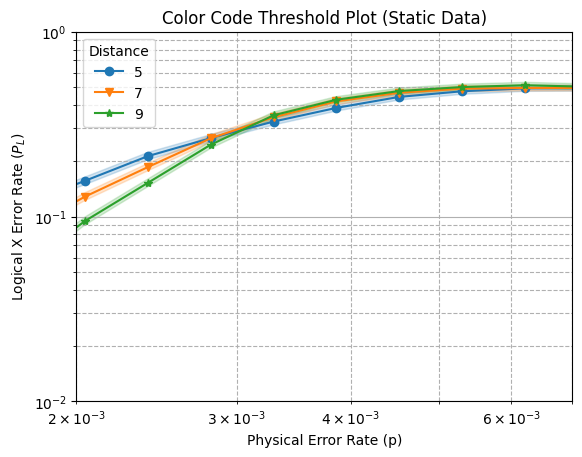

In [3]:
# closer analysis method to the paper
import sinter
import numpy as np
from scipy.optimize import curve_fit
from typing import List

# --- Model 1: Log-Space Scaling Threshold ---
# Fitting in log-space 
def log_scaling_threshold_model(data, log_c, p_th_star, alpha):
    p, d = data
    exponent = alpha * ((d + 1) / 2)
    # log(p_L) = log(c) + alpha * ((d+1)/2) * log(p / p_th_star)
    return log_c + exponent * np.log(p / p_th_star)

# --- Model 2: Cross Threshold 
def cross_threshold_model(data, A, B, C, p_th_cross, v_0):
    p, d = data
    x = (p - p_th_cross) * (d ** (1 / v_0))
    return A + B * x + C * (x ** 2)

def calculate_paper_thresholds(samples: List[sinter.TaskStats], estimated_crossing: float = 0.003, min_d_for_scaling: int = 7):
    
    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    errors = np.array([s.errors for s in samples])
    
    y = errors / shots
    
    # Statistical Weights
    y_err = np.sqrt(y * (1.0 - y) / shots)
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    popt_scale, popt_cross = None, None

    # --- 1. Fit Scaling Threshold (Eq 16 in Log Space) ---
    print("\n--- Calculating Scaling Threshold (Eq 16) ---")
    # Paper uses p <= p_th/2 and specifically uses higher distances (d=7, d=9)
    scale_mask = (ps <= (estimated_crossing * 0.5)) & (ds >= min_d_for_scaling)
    
    num_scale_points = np.sum(scale_mask)
    if num_scale_points >= 3:
        # Transform data and errors for log-space fit
        log_y = np.log(y[scale_mask])
        # Propagation of uncertainty: sigma_log(y) = sigma_y / y
        log_y_err = y_err[scale_mask] / y[scale_mask] 
        
        p0_scale = [np.log(0.13), estimated_crossing, 0.69] # Starting guesses based on paper's Table I
        bounds_scale = ([-np.inf, 0.0001, 0.1], [0.0, 0.05, 5.0])
        
        try:
            popt_scale_log, pcov_scale = curve_fit(
                log_scaling_threshold_model, 
                (ps[scale_mask], ds[scale_mask]), log_y, 
                p0=p0_scale, bounds=bounds_scale, maxfev=10000,
                sigma=log_y_err, absolute_sigma=True
            )
            perr_scale = np.sqrt(np.diag(pcov_scale))
            
            c_val = np.exp(popt_scale_log[0])
            p_th_star = popt_scale_log[1]
            alpha_val = popt_scale_log[2]
            
            print(f"p*_th (Scaling): {p_th_star:.7f} ± {perr_scale[1]:.7f}")
            print(f"c = {c_val:.5f}")
            print(f"alpha = {alpha_val:.5f} +/- {perr_scale[2]:.5f}")
        except Exception as e:
            print(f"Scaling Fit failed: {e}")
    else:
        print(f"Skipped: Found only {num_scale_points} valid points for scaling fit.")

    # --- 2. Fit Cross Threshold (Eq 17) ---
    print("\n--- Calculating Cross Threshold (Eq 17) ---")
    unique_ps = np.unique(ps)
    closest_ps = sorted(unique_ps, key=lambda p: abs(p - estimated_crossing))[:5]
    
    # Paper notes they use d=7, d=9 for the 6.6.6 code here as well. 
    # You may want to restrict `ds` here depending on your collected data.
    near_p_mask = np.isin(ps, closest_ps) & (ds >= min_d_for_scaling)
    
    num_cross_points = np.sum(near_p_mask)
    if num_cross_points >= 5:
        # 'A' is roughly the logical error rate at threshold, estimate it from the data
        approx_A = np.mean(y[near_p_mask]) 
        p0_cross = [approx_A, 10.0, 10.0, estimated_crossing, 1.0] 
        
        bounds_cross = (
            [0.0, -np.inf, -np.inf, 0.0001, 0.1], 
            [1.0,  np.inf,  np.inf, 0.05,  5.0]  
        )
        try:
            popt_cross, pcov_cross = curve_fit(
                cross_threshold_model, 
                (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                p0=p0_cross, bounds=bounds_cross, maxfev=10000,
                sigma=y_err[near_p_mask], absolute_sigma=True 
            )
            perr_cross = np.sqrt(np.diag(pcov_cross))
            print(f"p^x_th (Cross): {popt_cross[3]:.7f} ± {perr_cross[3]:.7f}")
        except Exception as e:
            print(f"Cross Fit failed: {e}")

    return popt_scale_log, popt_cross

def calculate_robust_thresholds(samples, estimated_crossing: float = 0.006, min_d: int = 7):

    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    errors = np.array([s.errors for s in samples])
    
    y = errors / shots
    
    # Statistical Weights
    y_err = np.sqrt(y * (1.0 - y) / shots)
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    popt_scale, popt_cross = None, None
    
    # --- 1. Robust Scaling Threshold (Eq 16 in Log Space) ---
    print("\n--- Calculating Robust Scaling Threshold ---")
    
    # STRICT cutoff: Must be deeply in the asymptotic regime (e.g., p <= 60% of crossing)
    scale_cutoff = estimated_crossing * 0.6
    scale_mask = (ps <= scale_cutoff) & (ds >= min_d)
    
    if np.sum(scale_mask) >= 3:
        log_y = np.log(y[scale_mask])
        log_y_err = y_err[scale_mask] / y[scale_mask] 
        
        # p0: [ln(c), p_th, alpha]
        p0_scale = [np.log(0.5), estimated_crossing, 1.0] 
        
        # BUGFIX: Allow ln(c) to be positive (meaning c > 1.0 is mathematically allowed)
        # Bounds: ([-inf, 0.0001, 0.1], [10.0, 0.05, 10.0])
        bounds_scale = ([-np.inf, 0.0001, 0.1], [10.0, 0.05, 10.0])
        
        try:
            popt_scale_log, pcov_scale = curve_fit(
                log_scaling_threshold_model, 
                (ps[scale_mask], ds[scale_mask]), log_y, 
                p0=p0_scale, bounds=bounds_scale, maxfev=20000,
                sigma=log_y_err, absolute_sigma=True
            )
            perr_scale = np.sqrt(np.diag(pcov_scale))
            
            c_val = np.exp(popt_scale_log[0])
            print(f"p*_th (Scaling): {popt_scale_log[1]:.7f} ± {perr_scale[1]:.7f}")
            print(f"c = {c_val:.5f}")
            print(f"alpha = {popt_scale_log[2]:.5f} +/- {perr_scale[2]:.5f}")
        except Exception as e:
            print(f"Scaling Fit failed: {e}")

    # --- 2. Robust Cross Threshold (Eq 17) ---
    print("\n--- Calculating Robust Cross Threshold ---")
    
    # Use a +/- 25% window around the estimated crossing instead of 5 points.
    lower_bound = estimated_crossing * 0.75
    upper_bound = estimated_crossing * 1.25
    
    near_p_mask = (ps >= lower_bound) & (ps <= upper_bound) & (ds >= min_d)
    num_cross_points = np.sum(near_p_mask)
    
    print(f"Using {num_cross_points} data points for cross-threshold fit...")
    
    if num_cross_points >= 6: # Need slightly more points for a robust window fit
        approx_A = np.mean(y[near_p_mask]) 
        p0_cross = [approx_A, 10.0, 10.0, estimated_crossing, 1.0] 
        
        bounds_cross = (
            [0.0, -np.inf, -np.inf, 0.001, 0.1], 
            [1.0,  np.inf,  np.inf, 0.05,  5.0]  
        )
        try:
            popt_cross, pcov_cross = curve_fit(
                cross_threshold_model, 
                (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                p0=p0_cross, bounds=bounds_cross, maxfev=20000,
                sigma=y_err[near_p_mask], absolute_sigma=True 
            )
            perr_cross = np.sqrt(np.diag(pcov_cross))
            print(f"p^x_th (Cross): {popt_cross[3]:.7f} ± {perr_cross[3]:.7f}")
            print(f"v_0 (Crit Exp): {popt_cross[4]:.5f} ± {perr_cross[4]:.5f}")
            
        except Exception as e:
            print(f"Cross Fit failed: {e}")

    return popt_scale_log, popt_cross
            
def analyze_and_plot():
    # 1. Load the frozen data from your hard drive
    with open("final_report_666_CC_XL_data.csv", "r") as f:
        samples = sinter.stats_from_csv_files(f)

    # 2. Calculate thresholds based on the STATIC dataset
    # (This will now give you the exact same number every time)
    #popt_scale, popt_cross = calculate_paper_thresholds(samples)
    popt_scale, popt_cross = calculate_robust_thresholds(samples, estimated_crossing=0.003)
    
    # 3. Plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1, 
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot (Static Data)")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical X Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    
    """
    if popt_scale is not None:
        ax.axvline(x=popt_scale[1], color='b', linestyle=':', label=f"Scaling th: {popt_scale[1]:.4f}")
    if popt_cross is not None:
        ax.axvline(x=popt_cross[3], color='r', linestyle='--', label=f"Cross th: {popt_cross[3]:.4f}")"""
    ax.set_xlim(2e-3, 7e-3)
    ax.set_ylim(1e-2,1)
    ax.legend(title='Distance')
    plt.savefig("ImplCCThresholdPlot_Final_XL.png")
    plt.show()

analyze_and_plot()

Loaded 117 'midout_color_code_Z' data points from stats.csv.


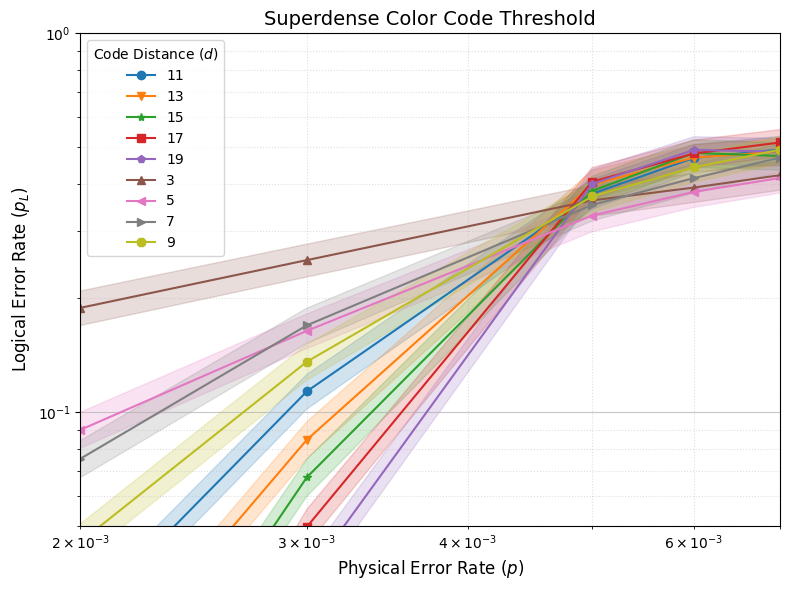


--- Calculating Robust Scaling Threshold ---
p*_th (Scaling): 0.0059180 ± 0.0000304
c = 1.33741
alpha = 0.59844 +/- 0.00123

--- Calculating Robust Cross Threshold ---
Using 14 data points for cross-threshold fit...
p^x_th (Cross): 0.0047211 ± 0.0000548
v_0 (Crit Exp): 1.11352 ± 0.07832


In [46]:
import sinter
from typing import List

def plot_sinter_thresholds(stats: List[sinter.TaskStats], title: str = "Superdense Color Code Threshold"):
    """
    Plots the logical error rate vs physical error rate, grouped by code distance.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    sinter.plot_error_rate(
        ax=ax,
        stats=stats,
        x_func=lambda stat: stat.json_metadata['p'], 
        group_func=lambda stat: stat.json_metadata['d']  
    )

    # Format the plot
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Physical Error Rate ($p$)', fontsize=12)
    ax.set_ylabel('Logical Error Rate ($p_L$)', fontsize=12)

    ax.grid(which='major', linestyle='-', alpha=0.7)
    ax.grid(which='minor', linestyle=':', alpha=0.4)
    ax.set_xlim(2e-3, 7e-3)
    ax.set_ylim(5e-2,1)
    ax.legend(title="Code Distance ($d$)", fontsize=10)
    plt.tight_layout()
    plt.show()

    
def load_and_filter_stats(csv_path: str, filter_keyword: str = "superdense") -> List[sinter.TaskStats]:
    """
    Reads a Sinter CSV file and extracts TaskStats objects that match a keyword.
    """
    filtered_stats = []
    try:
        all_stats = sinter.read_stats_from_csv_files(csv_path)
    except Exception as e:
        print(f"Failed to read Sinter CSV: {e}")
        return []

    for stat in all_stats:
        metadata_str = str(stat.json_metadata).lower()
        
        if filter_keyword.lower() in metadata_str:
            filtered_stats.append(stat)
            
    print(f"Loaded {len(filtered_stats)} '{filter_keyword}' data points from {csv_path}.")
    return filtered_stats

if __name__ == "__main__":
    csv_file_path = "stats.csv" 
    superdense_stats = load_and_filter_stats(csv_file_path, filter_keyword="midout_color_code_Z")
    
    if superdense_stats:
        plot_sinter_thresholds(superdense_stats)
        scale_fit, cross_fit = calculate_robust_thresholds(
            superdense_stats, 
            estimated_crossing=0.0040, 
            min_d=7 
        )


--- Sweeping for Optimal Crossing Point (0.004 to 0.007) ---

--- Sweep Complete ---
Optimal Data Window Centered At: 0.004000
Calculated p^x_th (Cross):       0.0047211 ± 0.0000548
Calculated v_0 (Crit Exp):       1.11352


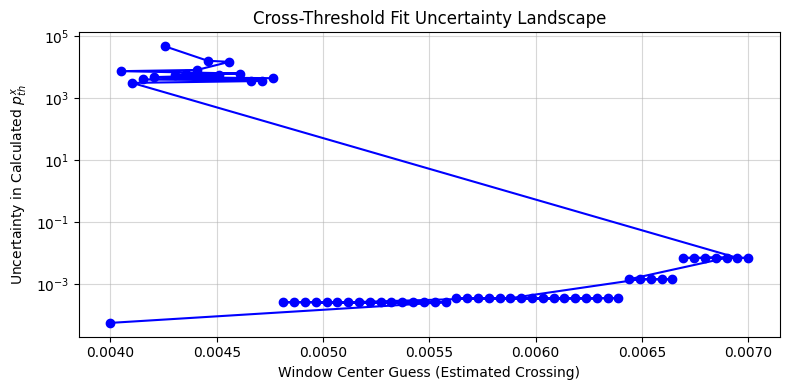

In [48]:
# searching for best crossing point
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import warnings
from scipy.optimize import OptimizeWarning

def find_best_crossing_point(samples, min_guess=0.003, max_guess=0.008, steps=50, min_d=7):
    """
    Sweeps through potential crossing points to find the fit with the lowest uncertainty.
    """
    print(f"\n--- Sweeping for Optimal Crossing Point ({min_guess} to {max_guess}) ---")

    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    errors = np.array([s.errors for s in samples])
    
    y = errors / shots
    y_err = np.sqrt(y * (1.0 - y) / shots)
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    guesses = np.linspace(min_guess, max_guess, steps)
    results = []


    with warnings.catch_warnings():
        warnings.simplefilter("ignore", OptimizeWarning)
        
        for guess in guesses:
            # Create a +/- 25% window around the current guess
            lower_bound = guess * 0.75
            upper_bound = guess * 1.25
            
            near_p_mask = (ps >= lower_bound) & (ps <= upper_bound) & (ds >= min_d)
            
            # Need at least 6 points to safely fit the 5 parameters of Eq 17
            if np.sum(near_p_mask) >= 6:
                approx_A = np.mean(y[near_p_mask]) 
                p0_cross = [approx_A, 10.0, 10.0, guess, 1.0] 
                
                bounds_cross = (
                    [0.0, -np.inf, -np.inf, 0.001, 0.1], 
                    [1.0,  np.inf,  np.inf, 0.05,  5.0]  
                )
                
                try:
                    popt_cross, pcov_cross = curve_fit(
                        cross_threshold_model, 
                        (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                        p0=p0_cross, bounds=bounds_cross, maxfev=10000,
                        sigma=y_err[near_p_mask], absolute_sigma=True 
                    )
                    
                    perr_cross = np.sqrt(np.diag(pcov_cross))
                    p_th_uncertainty = perr_cross[3]
                    calculated_p_th = popt_cross[3]
                    
                    # (Guess, Calculated Threshold, Uncertainty, Full popt)
                    results.append((guess, calculated_p_th, p_th_uncertainty, popt_cross))
                    
                except RuntimeError:
                    pass 

    if not results:
        print("Error: No valid fits found across the entire sweep range.")
        return None
        
    # Sort results by the uncertainty (index 2) to find the tightest fit
    results.sort(key=lambda x: x[2])
    best_result = results[0]
    
    print("\n--- Sweep Complete ---")
    print(f"Optimal Data Window Centered At: {best_result[0]:.6f}")
    print(f"Calculated p^x_th (Cross):       {best_result[1]:.7f} ± {best_result[2]:.7f}")
    print(f"Calculated v_0 (Crit Exp):       {best_result[3][4]:.5f}")
    

    _plot_error_landscape(results)
    
    return best_result[3] 

def _plot_error_landscape(results):
    guesses = [r[0] for r in results]
    uncertainties = [r[2] for r in results]
    
    plt.figure(figsize=(8, 4))
    plt.plot(guesses, uncertainties, marker='o', linestyle='-', color='b')
    plt.title("Cross-Threshold Fit Uncertainty Landscape")
    plt.xlabel("Window Center Guess (Estimated Crossing)")
    plt.ylabel("Uncertainty in Calculated $p^x_{th}$")
    plt.yscale('log')
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    #plt.savefig("sweep_landscape.png")

# Pass your parsed Chromobius stats to the sweep function
best_cross_params = find_best_crossing_point(
    superdense_stats, 
    min_guess=0.004, # Start slightly below your visual estimate
    max_guess=0.007, # End slightly above your visual estimate
    steps=60,        # Number of windows to test
    min_d=7          # Use only distances 7 through 19
)


--- Calculating Robust Scaling Threshold ---
p*_th (Scaling): 0.0044052 ± 0.0000309
c = 1.15298
alpha = 0.70461 +/- 0.00070

--- Calculating Robust Cross Threshold ---
Using 6 data points for cross-threshold fit...
p^x_th (Cross): 0.0031984 ± 0.0000946
v_0 (Crit Exp): 1.15481 ± 0.28854


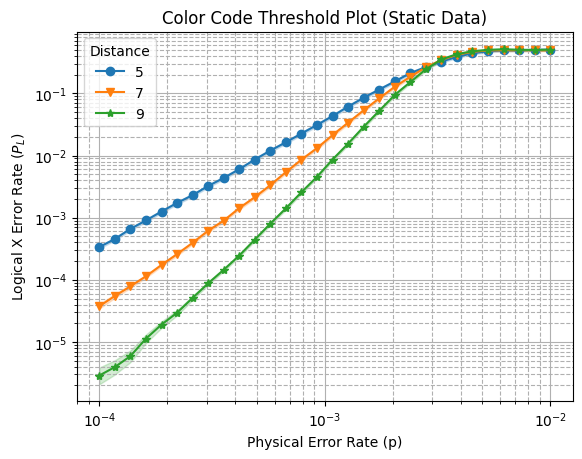


--- Sweeping for Optimal Crossing Point (0.002 to 0.006) ---

--- Sweep Complete ---
Optimal Data Window Centered At: 0.003627
Calculated p^x_th (Cross):       0.0032202 ± 0.0000915
Calculated v_0 (Crit Exp):       1.19237


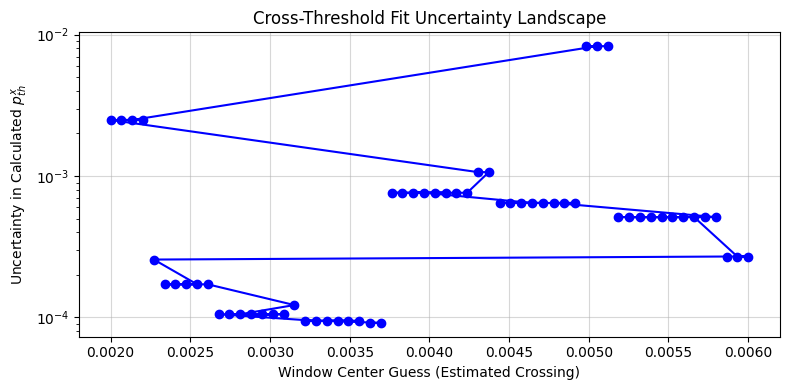

In [50]:
#evaluating color code thresholds -> run after data collection
import sinter
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from typing import List

# --- Model 1 ---
def scaling_threshold_model(data, c, p_th_star, alpha):
    p, d = data
    exponent = alpha * ((d + 1) / 2)
    # Using np.power and safe division to prevent warnings during optimization guesses
    return c * np.power(p / p_th_star, exponent)

# --- Model 2  ---
def cross_threshold_model(data, A, B, C, p_th_cross, v_0):
    p, d = data
    x = (p - p_th_cross) * (d ** (1 / v_0))
    return A + B * x + C * (x ** 2)


def calculate_paper_thresholds(samples: List[sinter.TaskStats], estimated_crossing: float = 0.003):
    
    # 1. Extract raw data cleanly
    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    errors = np.array([s.errors for s in samples])
    
    y = errors / shots
    
    y_err = np.sqrt(y * (1.0 - y) / shots)
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    popt_scale = None
    popt_cross = None

    # --- fit Scaling Threshold ---
    print("\n--- Calculating Scaling Threshold (Eq 16) ---")
    low_p_mask = ps < (estimated_crossing * 0.8) 
    num_scale_points = np.sum(low_p_mask)
    
    if num_scale_points >= 3:
        p0_scale = [1.0, estimated_crossing, 1.0]
        bounds_scale = ([0.0, 0.0001, 0.1], [np.inf, 0.05, 5.0])
        try:
            popt_scale, pcov_scale = curve_fit(
                scaling_threshold_model, (ps[low_p_mask], ds[low_p_mask]), y[low_p_mask], 
                p0=p0_scale, bounds=bounds_scale, maxfev=10000,
                sigma=y_err[low_p_mask], absolute_sigma=True
            )
            perr_scale = np.sqrt(np.diag(pcov_scale))
            #print(f"p*_th (Scaling): {popt_scale[1]:.5f} ± {perr_scale[1]:.5f}")
            print(f"p*_th (Scaling): {popt_scale[1]:.7f} ± {perr_scale[1]:.7f}")
            print(f"c = {popt_scale[0]:.5f} +/- {perr_scale[0]:.5f}")
            print(f"alpha = {popt_scale[2]:.5f} +/- {perr_scale[2]:.5f}")
        except Exception as e:
            print(f"Fit failed: {e}")
    else:
        print(f"Skipped: Found only {num_scale_points} data points below p={estimated_crossing * 0.8}. Need at least 3.")

    # --- Fit Cross Threshol ---
    print("\n--- Calculating Cross Threshold (Eq 17) ---")
    unique_ps = np.unique(ps)
    closest_ps = sorted(unique_ps, key=lambda p: abs(p - estimated_crossing))[:5]
    
    near_p_mask = np.isin(ps, closest_ps)
    num_cross_points = np.sum(near_p_mask)
    
    if num_cross_points >= 5:
        p0_cross = [0.1, 10.0, 10.0, estimated_crossing, 1.0] 
        bounds_cross = (
            [0.0, -np.inf, -np.inf, 0.0001, 0.1], 
            [1.0,  np.inf,  np.inf, 0.05,  5.0]  
        )
        try:
            popt_cross, pcov_cross = curve_fit(
                cross_threshold_model, (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                p0=p0_cross, bounds=bounds_cross, maxfev=10000,
                sigma=y_err[near_p_mask], absolute_sigma=True 
            )
            perr_cross = np.sqrt(np.diag(pcov_cross))
            #print(f"p^x_th (Cross): {popt_cross[3]:.5f} ± {perr_cross[3]:.5f}")
            print(f"p^x_th (Cross): {popt_cross[3]:.7f} ± {perr_cross[3]:.7f}")
        except Exception as e:
            print(f"Fit failed: {e}")
    else:
        print(f"Skipped: Found only {num_cross_points} points near threshold. Need at least 5 to fit Eq 17.")

    return popt_scale, popt_cross
            
def analyze_and_plot():
    with open("final_report_666_CC_XL_data.csv", "r") as f:
        samples = sinter.stats_from_csv_files(f)

    #popt_scale, popt_cross = calculate_paper_thresholds(samples)
    popt_scale, popt_cross = calculate_robust_thresholds(samples, estimated_crossing=0.0036)
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1, 
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot (Static Data)")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical X Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    
    """
    if popt_scale is not None:
        ax.axvline(x=popt_scale[1], color='b', linestyle=':', label=f"Scaling th: {popt_scale[1]:.4f}")
    if popt_cross is not None:
        ax.axvline(x=popt_cross[3], color='r', linestyle='--', label=f"Cross th: {popt_cross[3]:.4f}")"""
    #ax.set_xlim(2e-3, 7e-3)
    #ax.set_ylim(1e-2,1)
    ax.legend(title='Distance')
    #plt.savefig("ImplCCThresholdPlot_Final_XL.png")
    plt.show()

analyze_and_plot()

with open("final_report_666_CC_XL_data.csv", "r") as f:
    samples = sinter.stats_from_csv_files(f)
    
best_cross_params = find_best_crossing_point(
    samples, 
    min_guess=0.002, # Start slightly below your visual estimate
    max_guess=0.006, # End slightly above your visual estimate
    steps=60,        # Number of windows to test
    min_d=7          # Use only distances 7 through 19
)


--- Calculating Scaling Threshold (Eq 16) ---
p*_th (Scaling): 0.0038205 ± 0.0000144
c = 0.65514 +/- 0.00632
alpha = 0.69619 +/- 0.00070

--- Calculating Cross Threshold (Eq 17) ---
p^x_th (Cross): 0.0030755 ± 0.0000420


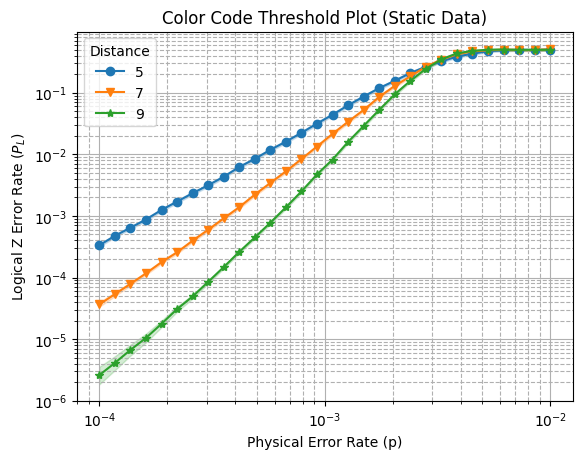

In [19]:
def analyze_and_plot_ZL():
    # 1. Load the frozen data from your hard drive
    with open("final_report_666_CC_ZL_data.csv", "r") as f:
        samples = sinter.stats_from_csv_files(f)

    # 2. Calculate thresholds based on the STATIC dataset
    # (This will now give you the exact same number every time)
    popt_scale, popt_cross = calculate_paper_thresholds(samples, estimated_crossing=0.0025)
    
    # 3. Plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1, 
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot (Static Data)")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical Z Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    
    """
    if popt_scale is not None:
        ax.axvline(x=popt_scale[1], color='b', linestyle=':', label=f"Scaling th: {popt_scale[1]:.4f}")
    if popt_cross is not None:
        ax.axvline(x=popt_cross[3], color='r', linestyle='--', label=f"Cross th: {popt_cross[3]:.4f}")"""
        
    ax.legend(title='Distance')
    #ax.set_xlim(2e-3, 7e-3)
    #ax.set_ylim(1e-2,1)
    plt.savefig("ImplCCThresholdPlot_Final_ZL.png")
    plt.show()

analyze_and_plot_ZL()

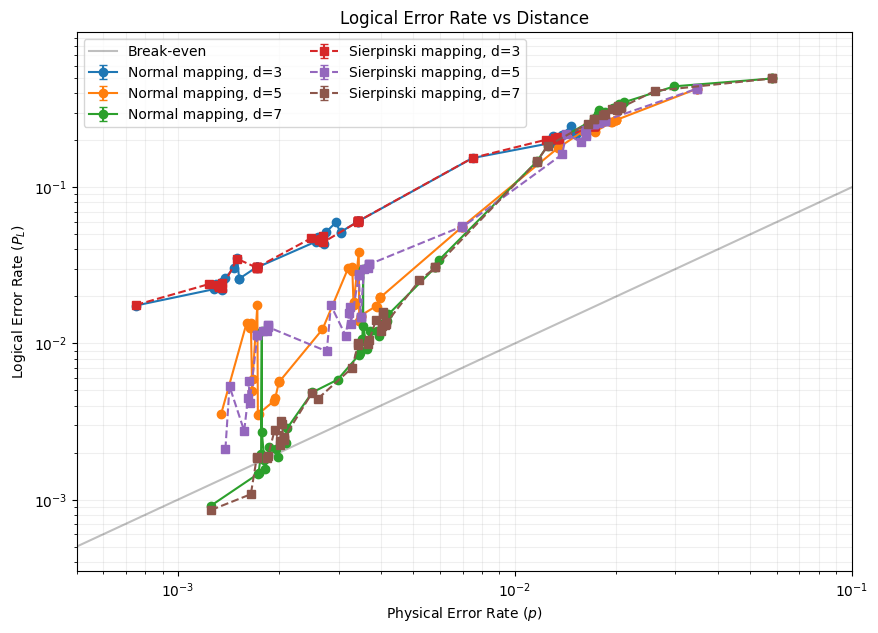

In [3]:
# want to plot difference between normal + sierpinski mapping - Logical error rate

#cc_data_path = r".\data\new_data\cc_internal_666_half.json"
#cc_tri_data_path = r".\data\new_data\cc_internal_666_sierp.json"

cc_data_path = r".\data\cc_halving_single_round040426.json"
cc_tri_data_path = r".\data\cc_bounded_nn_single_round040426.json"
with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
log_errs_dict = raw_data['LogicalErrorRates'][label]
log_errs_tri_dict = raw_tri_data['LogicalErrorRates'][label]
phys_x_dict = raw_data['PhysicalXErrorRates'][label]
phys_x_tri_dict = raw_tri_data['PhysicalXErrorRates'][label]
phys_z_dict = raw_data['PhysicalZErrorRates'][label]
phys_z_tri_dict = raw_tri_data['PhysicalZErrorRates'][label]

# Iterate through the nested structure
for d_str, cap_dict in log_errs_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        
        # Get corresponding physical error rates
        phys_x_list = phys_x_dict[d_str][cap_str]
        phys_z_list = phys_z_dict[d_str][cap_str]
        
        # Combine the lists into rows for our DataFrame
        for i, log_err in enumerate(log_err_list):
            px = phys_x_list[i]
            pz = phys_z_list[i]
            
            # Standard practice: define p as the average or max of X/Z errors
            p_physical = (px + pz) / 2
            
            records.append({
                'd': d,
                'capacity': capacity,
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': 1000000 
            })

for d_str, cap_dict in log_errs_tri_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        
        # Get corresponding physical error rates
        phys_x_list = phys_x_tri_dict[d_str][cap_str]
        phys_z_list = phys_z_tri_dict[d_str][cap_str]
        
        # Combine the lists into rows for our DataFrame
        for i, log_err in enumerate(log_err_list):
            px = phys_x_list[i]
            pz = phys_z_list[i]
            
            # Standard practice: define p as the average or max of X/Z errors
            p_physical = (px + pz) / 2
            
            records_tri.append({
                'd': d,
                'capacity': capacity,
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': 1000000 
            })
            
# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

plt.figure(figsize=(10, 7))

datasets = [
    (df, "Normal mapping", '-', 'o'),
    (df_tri, "Sierpinski mapping", '--', 's'),
]

for data, name, ls, marker in datasets:
    distances = sorted(data['d'].unique())

    for d in distances:
        subset = data[data['d'] == d].sort_values('p')

        subset['std_err'] = np.sqrt(
            subset['logical_error_rate']
            * (1 - subset['logical_error_rate'])
            / subset['shots']
        )

        plt.errorbar(
            subset['p'],
            subset['logical_error_rate'],
            yerr=subset['std_err'],
            label=f'{name}, d={d}',
            linestyle=ls,
            marker=marker,
            capsize=3
        )

# --- Styling ---
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate ($p$)')
plt.ylabel('Logical Error Rate ($P_L$)')
plt.xlim(5e-4, 1e-1)
plt.title('Logical Error Rate vs Distance')
plt.grid(True, which="both", alpha=0.2)

# Break-even line
lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1])
]
plt.plot(lims, lims, 'k-', alpha=0.25, label='Break-even')

plt.legend(ncol=2)
plt.show()


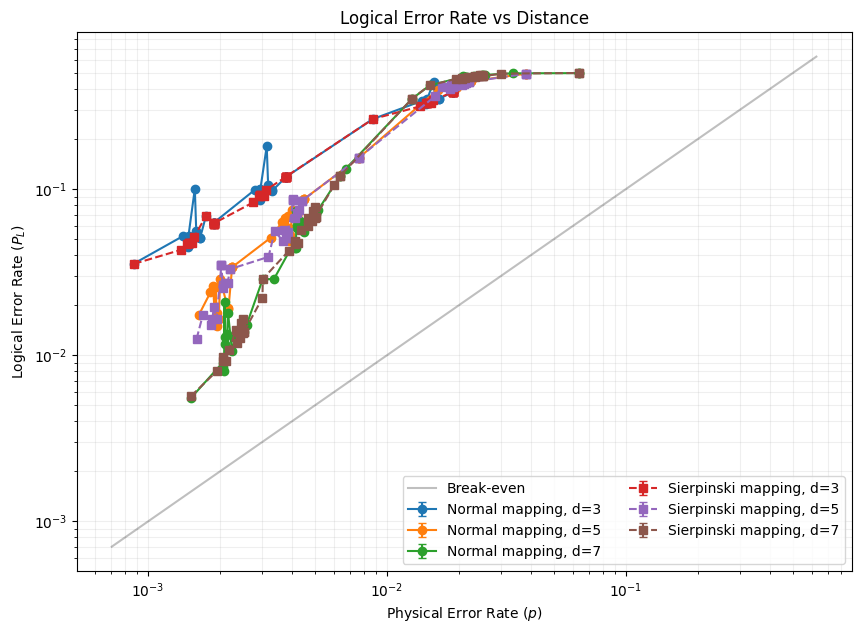

In [4]:
# want to plot difference between normal + sierpinski mapping - Logical error rate

cc_data_path = r".\data\cc_halving9326.json"
cc_tri_data_path = r".\data\cc_triangular_vec9326.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
log_errs_dict = raw_data['LogicalErrorRates'][label]
log_errs_tri_dict = raw_tri_data['LogicalErrorRates'][label]
phys_x_dict = raw_data['PhysicalXErrorRates'][label]
phys_x_tri_dict = raw_tri_data['PhysicalXErrorRates'][label]
phys_z_dict = raw_data['PhysicalZErrorRates'][label]
phys_z_tri_dict = raw_tri_data['PhysicalZErrorRates'][label]

# Iterate through the nested structure
for d_str, cap_dict in log_errs_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        
        # Get corresponding physical error rates
        phys_x_list = phys_x_dict[d_str][cap_str]
        phys_z_list = phys_z_dict[d_str][cap_str]
        
        # Combine the lists into rows for our DataFrame
        for i, log_err in enumerate(log_err_list):
            px = phys_x_list[i]
            pz = phys_z_list[i]
            
            # Standard practice: define p as the average or max of X/Z errors
            p_physical = (px + pz) / 2
            
            records.append({
                'd': d,
                'capacity': capacity,
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': 1000000 
            })

for d_str, cap_dict in log_errs_tri_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        
        # Get corresponding physical error rates
        phys_x_list = phys_x_tri_dict[d_str][cap_str]
        phys_z_list = phys_z_tri_dict[d_str][cap_str]
        
        # Combine the lists into rows for our DataFrame
        for i, log_err in enumerate(log_err_list):
            px = phys_x_list[i]
            pz = phys_z_list[i]
            
            # Standard practice: define p as the average or max of X/Z errors
            p_physical = (px + pz) / 2
            
            records_tri.append({
                'd': d,
                'capacity': capacity,
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': 1000000 
            })
            
# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

plt.figure(figsize=(10, 7))

datasets = [
    (df, "Normal mapping", '-', 'o'),
    (df_tri, "Sierpinski mapping", '--', 's'),
]

for data, name, ls, marker in datasets:
    distances = sorted(data['d'].unique())

    for d in distances:
        subset = data[data['d'] == d].sort_values('p')

        subset['std_err'] = np.sqrt(
            subset['logical_error_rate']
            * (1 - subset['logical_error_rate'])
            / subset['shots']
        )

        plt.errorbar(
            subset['p'],
            subset['logical_error_rate'],
            yerr=subset['std_err'],
            label=f'{name}, d={d}',
            linestyle=ls,
            marker=marker,
            capsize=3
        )

# --- Styling ---
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate ($p$)')
plt.ylabel('Logical Error Rate ($P_L$)')
#plt.xlim(1e-5, 0.5e-4)
plt.title('Logical Error Rate vs Distance')
plt.grid(True, which="both", alpha=0.2)

# Break-even line
lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1])
]
plt.plot(lims, lims, 'k-', alpha=0.25, label='Break-even')

plt.legend(ncol=2)
plt.show()


Average proportional difference: 7.120295493763818%
Average absolute proportional difference: 22.312568317887624%
    d  capacity  point_idx         p  logical_error_rate    shots
2   3         2          2  0.000749            0.017491  1000000
5   3         5          2  0.001282            0.022293  1000000
11  3         3          2  0.001300            0.023997  1000000
14  3         6          2  0.001349            0.024647  1000000
20  3         8          2  0.001355            0.022101  1000000
8   3         4          2  0.001380            0.026405  1000000
23  3         7          2  0.001471            0.030508  1000000
26  3        10          2  0.001520            0.025779  1000000
17  3         9          2  0.001520            0.025966  1000000
47  3        60          2  0.001717            0.030687  1000000
29  3        11          2  0.001717            0.030730  1000000
32  3        12          2  0.001717            0.030589  1000000
35  3        13          2  

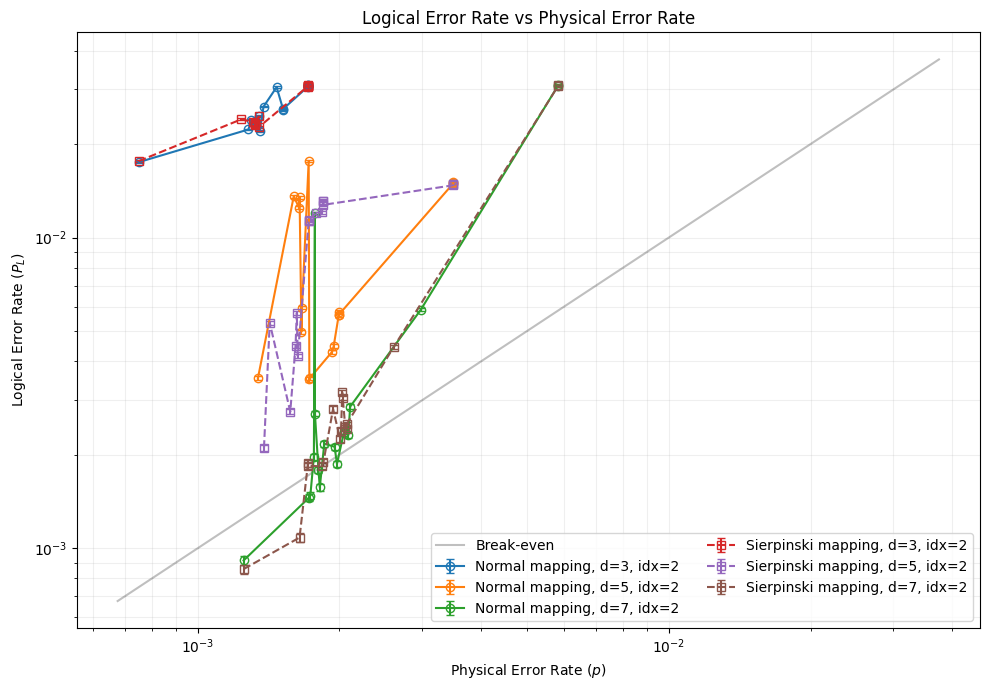

In [5]:
#triangular data uses the kd-tree bounded threshold merging 
#cc_data_path = r".\data\cc_halving9326.json"
#cc_tri_data_path = r".\data\cc_triangular_vec9326.json"

#uses single syndrome extraction round circuit:
cc_data_path = r".\data\cc_halving_single_round040426.json"
cc_tri_data_path = r".\data\cc_bounded_nn_single_round040426.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path, 'r') as f:
    raw_tri_data = json.load(f)

label = 'Forwarding'


log_errs_dict = raw_data['LogicalErrorRates'][label]
log_errs_tri_dict = raw_tri_data['LogicalErrorRates'][label]
phys_x_dict = raw_data['PhysicalXErrorRates'][label]
phys_x_tri_dict = raw_tri_data['PhysicalXErrorRates'][label]
phys_z_dict = raw_data['PhysicalZErrorRates'][label]
phys_z_tri_dict = raw_tri_data['PhysicalZErrorRates'][label]

records = []
records_tri = []
shots = 1000000 

# unpack the lists into individual rows
for d_str, cap_dict in log_errs_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        phys_x_list = phys_x_dict[d_str][cap_str]
        phys_z_list = phys_z_dict[d_str][cap_str]
        
        for i, log_err in enumerate(log_err_list):
            p_physical = (phys_x_list[i] + phys_z_list[i]) / 2
            records.append({
                'd': d,
                'capacity': capacity,
                'point_idx': i,          # Crucial for merging later
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': shots
            })

for d_str, cap_dict in log_errs_tri_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        phys_x_list = phys_x_tri_dict[d_str][cap_str]
        phys_z_list = phys_z_tri_dict[d_str][cap_str]
        
        for i, log_err in enumerate(log_err_list):
            p_physical = (phys_x_list[i] + phys_z_list[i]) / 2
            records_tri.append({
                'd': d,
                'capacity': capacity,
                'point_idx': i,          # Crucial for merging later
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': shots
            })


df_norm = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

# filter for common capacities 
common_caps = sorted(set(df_norm['capacity']).intersection(df_tri['capacity']))
df_norm = df_norm[df_norm['capacity'].isin(common_caps)].copy()
df_tri = df_tri[df_tri['capacity'].isin(common_caps)].copy()

# calc proportional & absolute difference
# Merge strictly by d, capacity, AND the list index to align the exact same data points
df_merged = pd.merge(
    df_norm, 
    df_tri, 
    on=['d', 'capacity', 'point_idx'], 
    suffixes=('_norm', '_tri')
)

df_merged = pd.merge(
    df_norm, 
    df_tri, 
    on=['d', 'capacity', 'point_idx'], 
    suffixes=('_norm', '_tri')
)

# keep rows where the baseline error rate is greater than 0
valid_merged = df_merged[df_merged['logical_error_rate_norm'] > 0].copy()

valid_merged['prop_diff'] = (valid_merged['logical_error_rate_tri'] - valid_merged['logical_error_rate_norm']) / valid_merged['logical_error_rate_norm']

avg_prop_diff = valid_merged['prop_diff'].mean()
avg_abs_prop_diff = valid_merged['prop_diff'].abs().mean()

print(f"Average proportional difference: {avg_prop_diff * 100}%")
print(f"Average absolute proportional difference: {avg_abs_prop_diff * 100}%")

# plots
plt.figure(figsize=(10, 7))

datasets = [
    (df_norm, "Normal mapping", '-', 'o'),
    (df_tri, "Sierpinski mapping", '--', 's'),
]

for data, name, ls, marker in datasets:
    distances = sorted(data['d'].unique())
    
    for d in distances:
        d_subset = data[data['d'] == d]
        
        for point_idx in sorted(d_subset['point_idx'].unique()):
            subset = d_subset[d_subset['point_idx'] == point_idx].sort_values('p')
        print(subset)
        subset = subset[subset['logical_error_rate'] > 0] 
        
        subset['std_err'] = np.sqrt(
            subset['logical_error_rate'] * (1 - subset['logical_error_rate']) / subset['shots']
        )
        
        plt.errorbar(
            subset['p'],
            subset['logical_error_rate'],
            yerr=subset['std_err'],
            label=f'{name}, d={d}, idx={point_idx}',
            linestyle=ls,
            marker=marker,
            markerfacecolor='none',  # Hollow markers!
            capsize=3
        )


plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate ($p$)')
plt.ylabel('Logical Error Rate ($P_L$)')

#plt.xlim(5e-6, 1e-4) 

plt.title('Logical Error Rate vs Physical Error Rate')
plt.grid(True, which="both", alpha=0.2)

# Break-even line
lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1])
]
plt.plot(lims, lims, 'k-', alpha=0.25, label='Break-even')

plt.legend(ncol=2)
plt.tight_layout()
plt.show()

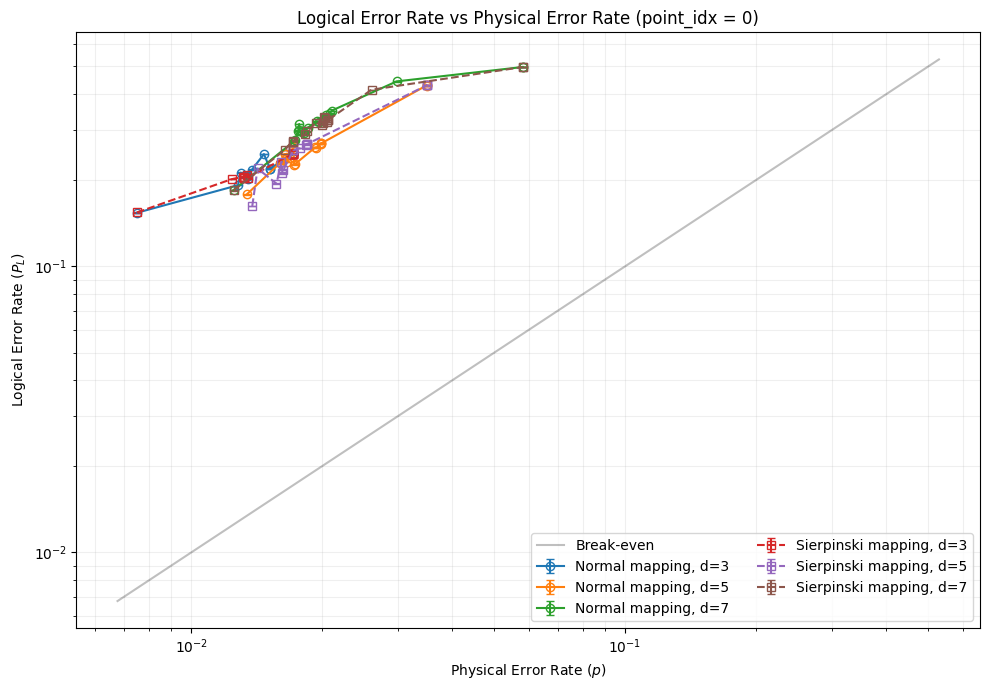

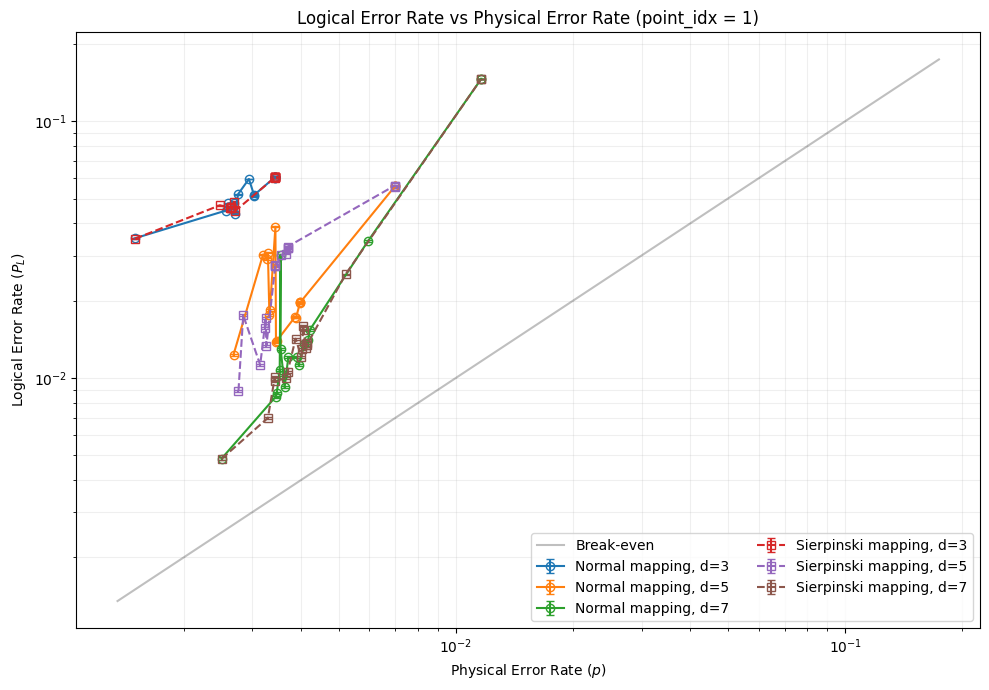

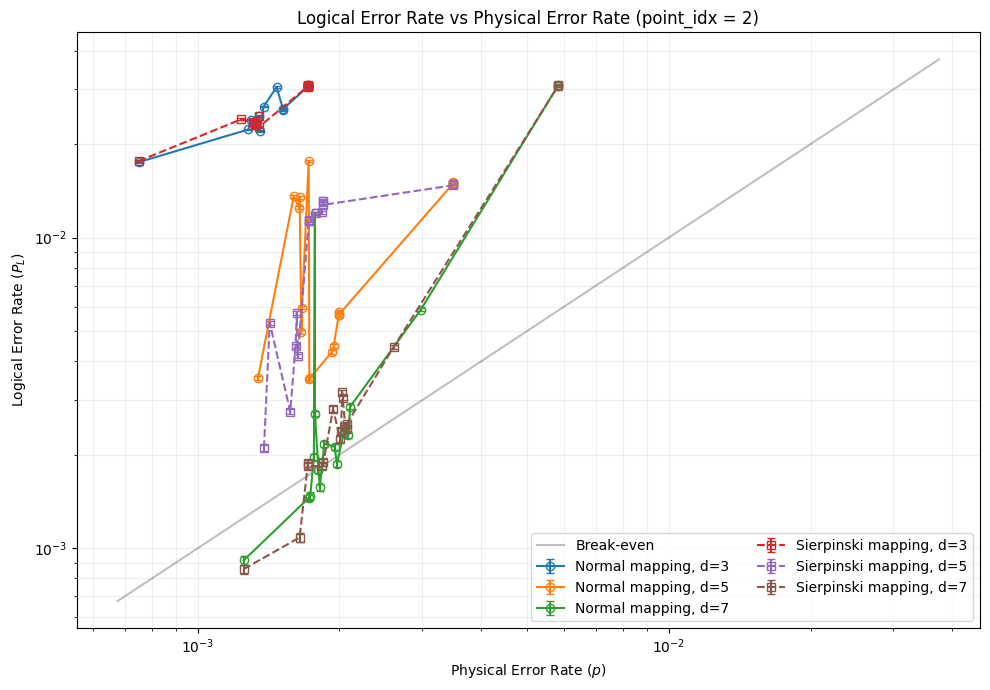

In [6]:
# plots: one figure per point_idx
unique_point_idxs = sorted(df_norm['point_idx'].unique())

for point_idx in unique_point_idxs:
    plt.figure(figsize=(10, 7))
    
    datasets = [
        (df_norm, "Normal mapping", '-', 'o'),
        (df_tri, "Sierpinski mapping", '--', 's'),
    ]
    
    for data, name, ls, marker in datasets:
        # filter this dataset for the current point_idx
        data_idx = data[data['point_idx'] == point_idx]
        
        distances = sorted(data_idx['d'].unique())
        
        for d in distances:
            subset = data_idx[data_idx['d'] == d].sort_values('p')
            subset = subset[subset['logical_error_rate'] > 0]
            
            # compute standard error
            subset['std_err'] = np.sqrt(
                subset['logical_error_rate'] * (1 - subset['logical_error_rate']) / subset['shots']
            )
            
            plt.errorbar(
                subset['p'],
                subset['logical_error_rate'],
                yerr=subset['std_err'],
                label=f'{name}, d={d}',
                linestyle=ls,
                marker=marker,
                markerfacecolor='none',
                capsize=3
            )
    
    # log scales
    plt.xscale('log')
    plt.yscale('log')
    
    plt.xlabel('Physical Error Rate ($p$)')
    plt.ylabel('Logical Error Rate ($P_L$)')
    
    plt.title(f'Logical Error Rate vs Physical Error Rate (point_idx = {point_idx})')
    plt.grid(True, which="both", alpha=0.2)
    
    # break-even line
    lims = [
        min(plt.xlim()[0], plt.ylim()[0]),
        max(plt.xlim()[1], plt.ylim()[1])
    ]
    plt.plot(lims, lims, 'k-', alpha=0.25, label='Break-even')
    
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

Average Proportional Difference (%) by Capacity and Code Distance (d):
-----------------------------------------------------------------
Negative values (Blue) = Sierpinski has LOWER error rates (Better).
Positive values (Red)  = Sierpinski has HIGHER error rates (Worse).

d             3      5      7
capacity                     
2         -0.21   4.25   0.82
3        -14.95   1.55  -7.57
4         -5.99 -25.80 -20.07
5         -6.28 -29.85  -0.82
6         -7.57 -10.69 -16.41
7        -42.51 -18.75 -13.41
8          5.22  23.53   1.09
9         -6.08  72.73  58.24
10        -6.18  61.15   7.84
11         0.13  12.38  -3.80
12        -0.32  19.01  12.07
13        -0.07 -12.30  -3.38
14         0.08  -1.80  -1.63
15         0.07  -1.90  -6.98
30         0.07  -0.15 -14.29
60        -0.38  -0.05   0.09
120       -0.24  -0.07   0.11




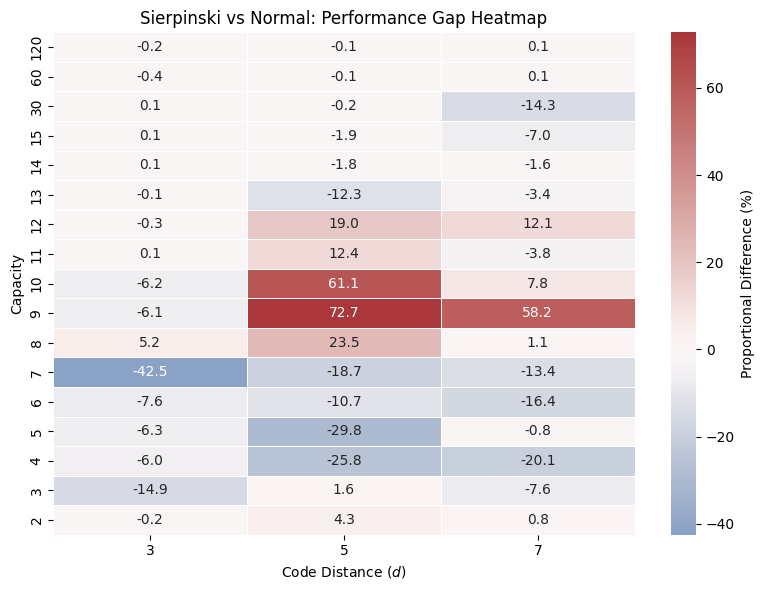

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#triangular data uses the kd-tree bounded threshold merging 

# group by 'd' and 'capacity' and get mean proportional difference
summary_df = valid_merged.groupby(['d', 'capacity'])['prop_diff'].mean().reset_index()
summary_df['prop_diff_%'] = summary_df['prop_diff'] * 100

# Pivot Table (Rows = capacity, Columns = d)
pivot_table = summary_df.pivot(index='capacity', columns='d', values='prop_diff_%')

print("Average Proportional Difference (%) by Capacity and Code Distance (d):")
print("-" * 65)
print("Negative values (Blue) = Sierpinski has LOWER error rates (Better).")
print("Positive values (Red)  = Sierpinski has HIGHER error rates (Worse).\n")
print(pivot_table.round(2))
print("\n")

# heatmap 
plt.figure(figsize=(8, 6))

# cmap="vlag" creates a blue (negative) to red (positive) gradient centered at 0
sns.heatmap(
    pivot_table, 
    annot=True,       # Prints the actual numbers inside the boxes
    fmt=".1f",        # Formats numbers to 1 decimal place
    cmap="vlag", 
    center=0,         # Forces white to be exactly 0% difference
    cbar_kws={'label': 'Proportional Difference (%)'},
    linewidths=0.5
)

plt.title("Sierpinski vs Normal: Performance Gap Heatmap")
plt.xlabel("Code Distance ($d$)")
plt.ylabel("Capacity")

# Invert y-axis so smaller capacities are at the top (optional, adjust to preference!)
plt.gca().invert_yaxis() 

plt.tight_layout()
plt.show()

Average proportional difference: 2957.781720559434%
Average absolute proportional difference: 2957.781814808465%


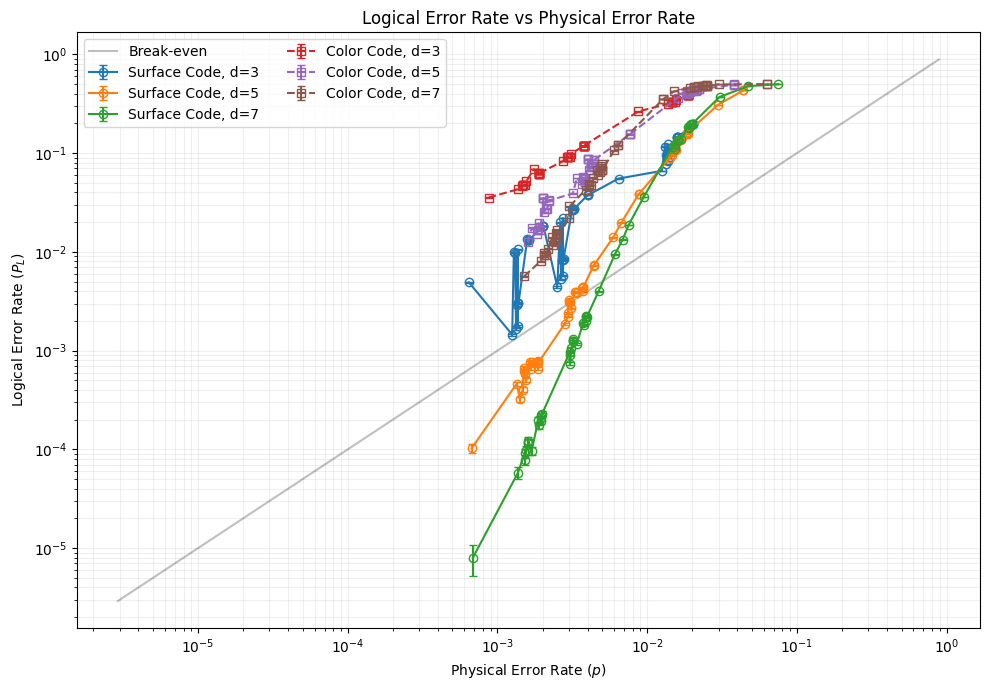

In [6]:
# SURFACE VS COLOR CODE
cc_data_path = r".\data\surface_halving13326.json"
cc_tri_data_path = r".\data\cc_triangular_vec9326.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path, 'r') as f:
    raw_tri_data = json.load(f)

label = 'Forwarding'


log_errs_dict = raw_data['LogicalErrorRates'][label]
log_errs_tri_dict = raw_tri_data['LogicalErrorRates'][label]
phys_x_dict = raw_data['PhysicalXErrorRates'][label]
phys_x_tri_dict = raw_tri_data['PhysicalXErrorRates'][label]
phys_z_dict = raw_data['PhysicalZErrorRates'][label]
phys_z_tri_dict = raw_tri_data['PhysicalZErrorRates'][label]

records = []
records_tri = []
shots = 1000000 

# unpack the lists into individual rows
for d_str, cap_dict in log_errs_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        phys_x_list = phys_x_dict[d_str][cap_str]
        phys_z_list = phys_z_dict[d_str][cap_str]
        
        for i, log_err in enumerate(log_err_list):
            p_physical = (phys_x_list[i] + phys_z_list[i]) / 2
            records.append({
                'd': d,
                'capacity': capacity,
                'point_idx': i,          # Crucial for merging later
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': shots
            })

for d_str, cap_dict in log_errs_tri_dict.items():
    d = int(d_str)
    for cap_str, log_err_list in cap_dict.items():
        capacity = int(cap_str)
        phys_x_list = phys_x_tri_dict[d_str][cap_str]
        phys_z_list = phys_z_tri_dict[d_str][cap_str]
        
        for i, log_err in enumerate(log_err_list):
            p_physical = (phys_x_list[i] + phys_z_list[i]) / 2
            records_tri.append({
                'd': d,
                'capacity': capacity,
                'point_idx': i,          # Crucial for merging later
                'p': p_physical,
                'logical_error_rate': log_err,
                'shots': shots
            })


df_norm = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

# filter for common capacities 
common_caps = sorted(set(df_norm['capacity']).intersection(df_tri['capacity']))
df_norm = df_norm[df_norm['capacity'].isin(common_caps)].copy()
df_tri = df_tri[df_tri['capacity'].isin(common_caps)].copy()

# calc proportional & absolute difference
# Merge strictly by d, capacity, AND the list index to align the exact same data points
df_merged = pd.merge(
    df_norm, 
    df_tri, 
    on=['d', 'capacity', 'point_idx'], 
    suffixes=('_norm', '_tri')
)

df_merged = pd.merge(
    df_norm, 
    df_tri, 
    on=['d', 'capacity', 'point_idx'], 
    suffixes=('_norm', '_tri')
)

# keep rows where the baseline error rate is greater than 0
valid_merged = df_merged[df_merged['logical_error_rate_norm'] > 0].copy()

valid_merged['prop_diff'] = (valid_merged['logical_error_rate_tri'] - valid_merged['logical_error_rate_norm']) / valid_merged['logical_error_rate_norm']

avg_prop_diff = valid_merged['prop_diff'].mean()
avg_abs_prop_diff = valid_merged['prop_diff'].abs().mean()

print(f"Average proportional difference: {avg_prop_diff * 100}%")
print(f"Average absolute proportional difference: {avg_abs_prop_diff * 100}%")

# plots
plt.figure(figsize=(10, 7))

datasets = [
    (df_norm, "Surface Code", '-', 'o'),
    (df_tri, "Color Code", '--', 's'),
]

for data, name, ls, marker in datasets:
    distances = sorted(data['d'].unique())
    
    for d in distances:
        subset = data[data['d'] == d].sort_values('p')
        
        # ADD THIS LINE: Drop 0.0 error rates so log-scale doesn't break
        subset = subset[subset['logical_error_rate'] > 0] 
        
        subset['std_err'] = np.sqrt(
            subset['logical_error_rate'] * (1 - subset['logical_error_rate']) / subset['shots']
        )
        
        plt.errorbar(
            subset['p'],
            subset['logical_error_rate'],
            yerr=subset['std_err'],
            label=f'{name}, d={d}',
            linestyle=ls,
            marker=marker,
            markerfacecolor='none',  # Hollow markers!
            capsize=3
        )


plt.xscale('log')
plt.yscale('log')
plt.xlabel('Physical Error Rate ($p$)')
plt.ylabel('Logical Error Rate ($P_L$)')

#plt.xlim(5e-6, 1e-4) 

plt.title('Logical Error Rate vs Physical Error Rate')
plt.grid(True, which="both", alpha=0.2)

# Break-even line
lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1])
]
plt.plot(lims, lims, 'k-', alpha=0.25, label='Break-even')

plt.legend(ncol=2)
plt.tight_layout()
plt.show()

   d  capacity  op_num    shots experiment
0  3        11     317  1000000     Normal
1  3        12     317  1000000     Normal
2  3        13     317  1000000     Normal
3  3         9     498  1000000     Normal
4  3        14     317  1000000     Normal
   d  capacity  op_num    shots  experiment
0  3        11     317  1000000  Sierpinski
1  3        12     317  1000000  Sierpinski
2  3        13     317  1000000  Sierpinski
3  3        14     317  1000000  Sierpinski
4  3        15     317  1000000  Sierpinski


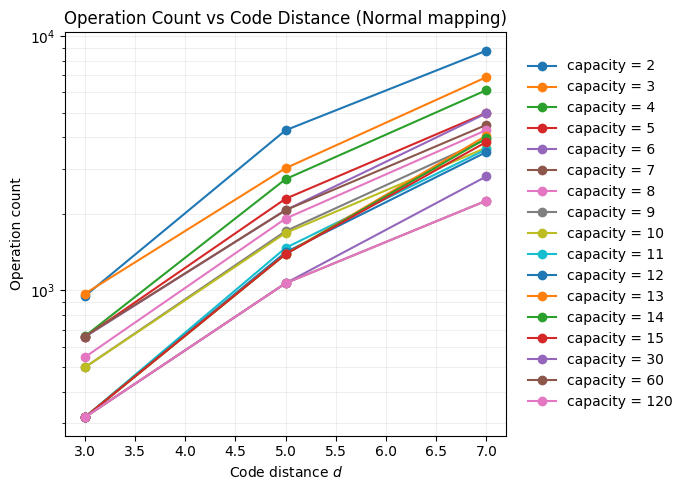

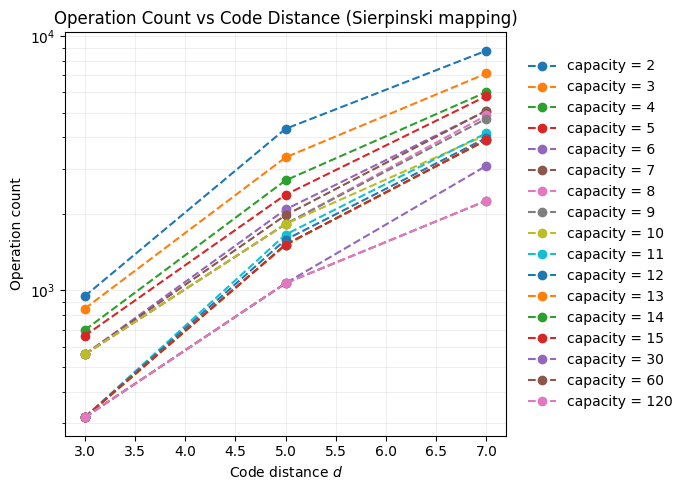

In [3]:
# want to plot difference between normal + sierpinski mapping - Operation count

#cc_data_path = r".\data\new_data\cc_internal_666_half.json"
#cc_tri_data_path = r".\data\new_data\cc_internal_666_sierp.json"

cc_data_path = r".\data\cc_halving7326.json"
cc_tri_data_path = r".\data\cc_triangular_vec7326.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['Operations'][label]
ops_tri_dict = raw_tri_data['Operations'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)
df['experiment'] = 'Normal'
df_tri['experiment'] = 'Sierpinski'
df_all = pd.concat([df, df_tri], ignore_index=True)

print(df.head())
print(df_tri.head())

linestyles = {'Normal':'-', 'Sierpinski':'--'}

for experiment in ['Normal', 'Sierpinski']:
    plt.figure(figsize=(7, 5))
    data = df_all[df_all['experiment'] == experiment]

    for i, capacity in enumerate(sorted(data['capacity'].unique())):
        subset = data[data['capacity'] == capacity].sort_values('d')

        plt.plot(
            subset['d'],
            subset['op_num'],
            linestyle=linestyles[experiment],
            marker='o',
            label=f'capacity = {capacity}'
        )

    plt.xlabel('Code distance $d$')
    plt.ylabel('Operation count')
    plt.yscale('log')
    plt.title(f'Operation Count vs Code Distance ({experiment} mapping)')
    plt.grid(True, which='both', alpha=0.2)
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )
    plt.tight_layout()
    plt.show()



Common capacities: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 30, 60, 120]
Average proportional difference: 3.55%
Average absolute proportional difference: 5.89%
    d  capacity  op_num    shots  experiment
4   3         5     656  1000000      Normal
25  5         5    2292  1000000      Normal
34  7         5    4983  1000000      Normal
59  3         5     663  1000000  Sierpinski
75  5         5    2377  1000000  Sierpinski
88  7         5    5802  1000000  Sierpinski


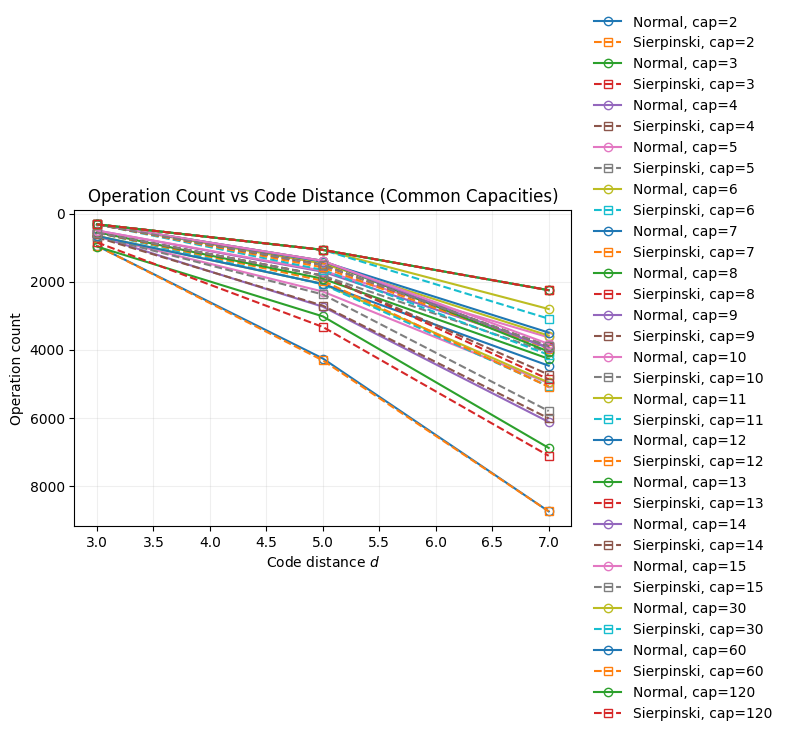

In [9]:
# want to plot difference between normal + sierpinski mapping (vectorised)- Operations - plot only common capacities

cc_data_path = r".\data\cc_halving9326.json"
cc_tri_data_path = r".\data\cc_triangular_vec9326.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['Operations'][label]
ops_tri_dict = raw_tri_data['Operations'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

common_caps = sorted(
    set(df['capacity']).intersection(df_tri['capacity'])
)

print("Common capacities:", common_caps)
df_common = df[df['capacity'].isin(common_caps)].copy()
df_tri_common = df_tri[df_tri['capacity'].isin(common_caps)].copy()

df_common['experiment'] = 'Normal'
df_tri_common['experiment'] = 'Sierpinski'

# 1. Merge aligning strictly by 'd' and 'capacity'
df_merged = pd.merge(
    df_common, 
    df_tri_common, 
    on=['d', 'capacity'], 
    suffixes=('_norm', '_tri')
)

# 2. Calculate the proportional difference for each pair
df_merged['prop_diff'] = (df_merged['op_num_tri'] - df_merged['op_num_norm']) / df_merged['op_num_norm']

# 3. Get the average metric
avg_prop_diff = df_merged['prop_diff'].mean()

# Absolute proportional difference (if you just care about magnitude, not direction)
avg_abs_prop_diff = df_merged['prop_diff'].abs().mean()

print(f"Average proportional difference: {avg_prop_diff * 100:.2f}%")
print(f"Average absolute proportional difference: {avg_abs_prop_diff * 100:.2f}%")

df_all = pd.concat([df_common, df_tri_common], ignore_index=True)

print(df_all[df_all['capacity']==5])
plt.figure(figsize=(8, 6))

linestyles = {'Normal': '-', 'Sierpinski': '--'}
markers = {'Normal': 'o', 'Sierpinski': 's'}

for (capacity, experiment), subset in df_all.groupby(['capacity', 'experiment']):
    subset = subset.sort_values('d')

    plt.plot(
        subset['d'],
        subset['op_num'],
        linestyle=linestyles[experiment],
        marker=markers[experiment],
        markerfacecolor='none',  # Makes the markers hollow!
        label=f'{experiment}, cap={capacity}'
    )

plt.xlabel('Code distance $d$')
plt.ylabel('Operation count')

# Invert the y-axis!
plt.gca().invert_yaxis()

#plt.yscale('log') # (Note: log scales also work perfectly fine when inverted)
plt.title('Operation Count vs Code Distance (Common Capacities)')
plt.grid(True, which='both', alpha=0.2)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.show()


   d  capacity    op_num    shots experiment
0  3         9  0.015630  1000000     Normal
1  3         8  0.014005  1000000     Normal
2  3        13  0.011360  1000000     Normal
3  3        11  0.011360  1000000     Normal
4  3        12  0.011360  1000000     Normal
   d  capacity    op_num    shots  experiment
0  3         6  0.014515  1000000  Sierpinski
1  3         8  0.015915  1000000  Sierpinski
2  3        12  0.011360  1000000  Sierpinski
3  3        10  0.015915  1000000  Sierpinski
4  3        13  0.011360  1000000  Sierpinski


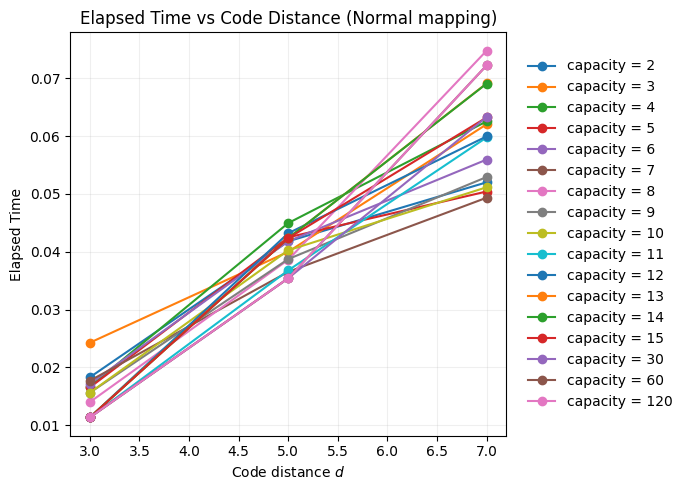

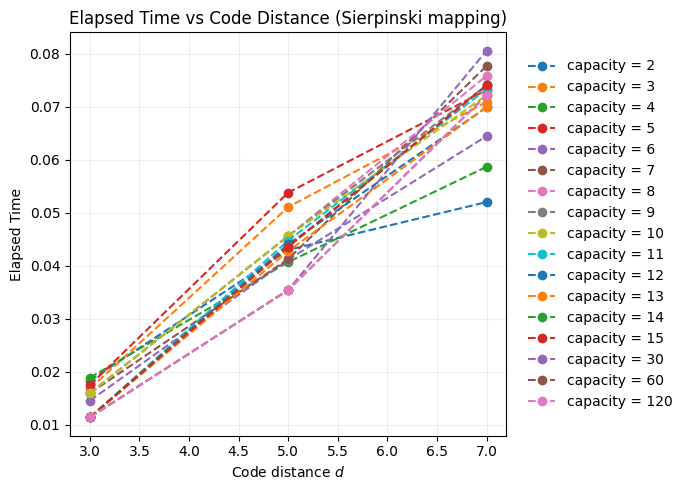

In [6]:
# want to plot difference between normal + sierpinski mapping - Elapsed Time

cc_data_path = r".\data\new_data\cc_internal_666_half.json"
cc_tri_data_path = r".\data\new_data\cc_internal_666_sierp.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['ElapsedTime'][label]
ops_tri_dict = raw_tri_data['ElapsedTime'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)
df['experiment'] = 'Normal'
df_tri['experiment'] = 'Sierpinski'
df_all = pd.concat([df, df_tri], ignore_index=True)

print(df.head())
print(df_tri.head())

linestyles = {'Normal':'-', 'Sierpinski':'--'}

for experiment in ['Normal', 'Sierpinski']:
    plt.figure(figsize=(7, 5))
    data = df_all[df_all['experiment'] == experiment]

    for i, capacity in enumerate(sorted(data['capacity'].unique())):
        subset = data[data['capacity'] == capacity].sort_values('d')

        plt.plot(
            subset['d'],
            subset['op_num'],
            linestyle=linestyles[experiment],
            marker='o',
            label=f'capacity = {capacity}'
        )

    plt.xlabel('Code distance $d$')
    plt.ylabel('Elapsed Time')
    #plt.yscale('log')
    plt.title(f'Elapsed Time vs Code Distance ({experiment} mapping)')
    plt.grid(True, which='both', alpha=0.2)
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )
    plt.tight_layout()
    plt.show()



Common capacities: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 30, 60, 120]
Empty DataFrame
Columns: [d, capacity, op_num, shots, experiment]
Index: []


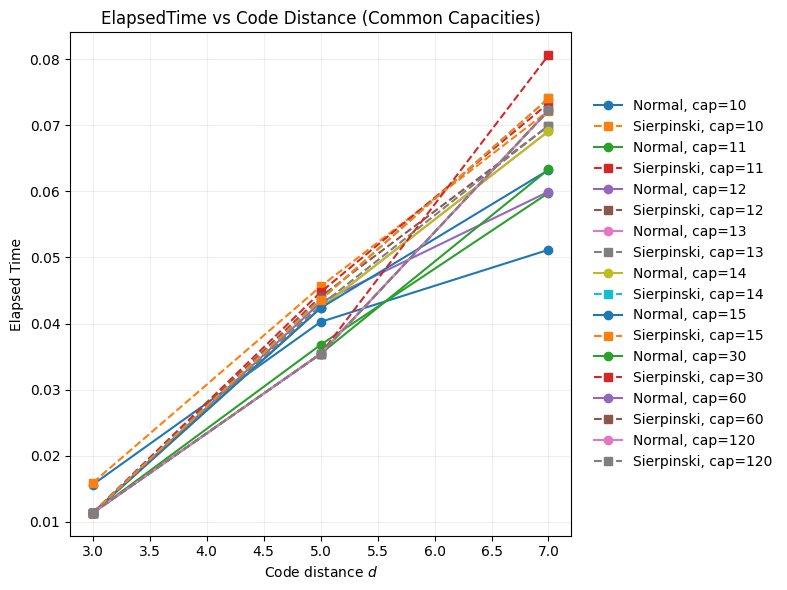

In [15]:
# want to plot difference between normal + sierpinski mapping - ElapsedTime - plot only common capacities

cc_data_path = r".\data\new_data\cc_internal_666_half.json"
cc_tri_data_path = r".\data\new_data\cc_internal_666_sierp.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['ElapsedTime'][label]
ops_tri_dict = raw_tri_data['ElapsedTime'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

common_caps = sorted(
    set(df['capacity']).intersection(df_tri['capacity'])
)

print("Common capacities:", common_caps)
df_common = df[df['capacity'].isin(common_caps)].copy()
df_tri_common = df_tri[df_tri['capacity'].isin(common_caps)].copy()

df_common['experiment'] = 'Normal'
df_tri_common['experiment'] = 'Sierpinski'
df_all = pd.concat([df_common, df_tri_common], ignore_index=True)
df_all = df_all[df_all['capacity']>=10]
print(df_all[df_all['capacity']==5])
plt.figure(figsize=(8, 6))

linestyles = {'Normal': '-', 'Sierpinski': '--'}
markers = {'Normal': 'o', 'Sierpinski': 's'}

for (capacity, experiment), subset in df_all.groupby(['capacity', 'experiment']):
    subset = subset.sort_values('d')

    plt.plot(
        subset['d'],
        subset['op_num'],
        linestyle=linestyles[experiment],
        marker=markers[experiment],
        label=f'{experiment}, cap={capacity}'
    )

plt.xlabel('Code distance $d$')
plt.ylabel('Elapsed Time')
#plt.yscale('log')
plt.title('ElapsedTime vs Code Distance (Common Capacities)')
plt.grid(True, which='both', alpha=0.2)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.show()


Common capacities: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 30, 60, 120]
Average proportional difference: 7.65%
Average absolute proportional difference: 10.71%
    d  capacity    op_num    shots  experiment
4   3         5  0.016550  1000000      Normal
25  5         5  0.042495  1000000      Normal
34  7         5  0.050420  1000000      Normal
59  3         5  0.017435  1000000  Sierpinski
75  5         5  0.053800  1000000  Sierpinski
88  7         5  0.073160  1000000  Sierpinski


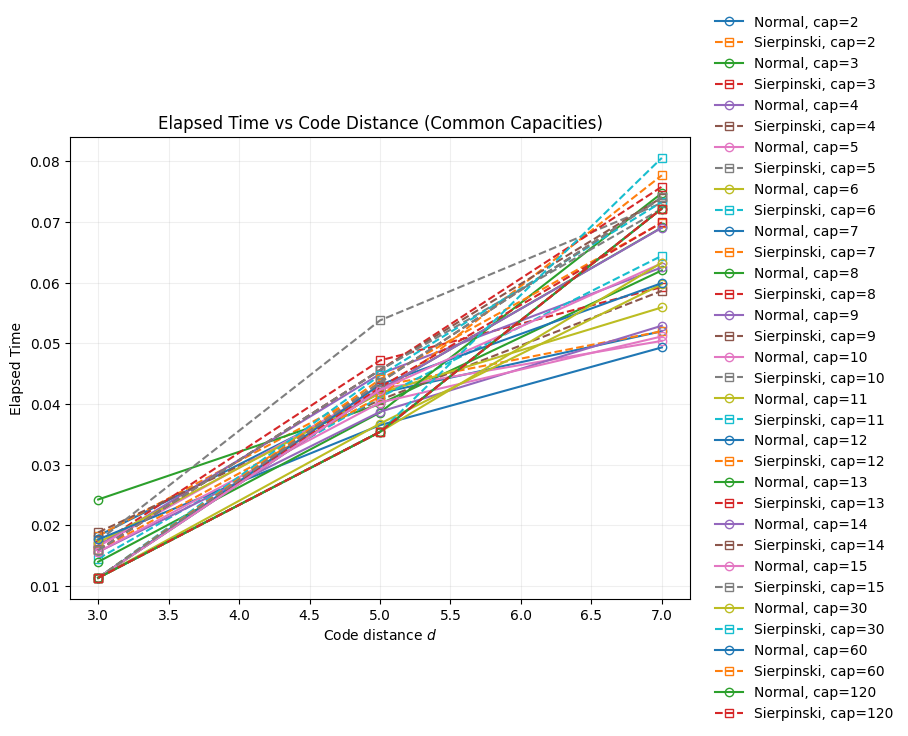

In [10]:
cc_data_path = r".\data\cc_halving9326.json"
cc_tri_data_path = r".\data\cc_triangular_vec9326.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['ElapsedTime'][label]
ops_tri_dict = raw_tri_data['ElapsedTime'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

common_caps = sorted(
    set(df['capacity']).intersection(df_tri['capacity'])
)

print("Common capacities:", common_caps)
df_common = df[df['capacity'].isin(common_caps)].copy()
df_tri_common = df_tri[df_tri['capacity'].isin(common_caps)].copy()

df_common['experiment'] = 'Normal'
df_tri_common['experiment'] = 'Sierpinski'

# 1. Merge aligning strictly by 'd' and 'capacity'
df_merged = pd.merge(
    df_common, 
    df_tri_common, 
    on=['d', 'capacity'], 
    suffixes=('_norm', '_tri')
)

# 2. Calculate the proportional difference for each pair
df_merged['prop_diff'] = (df_merged['op_num_tri'] - df_merged['op_num_norm']) / df_merged['op_num_norm']

# 3. Get the average metric
avg_prop_diff = df_merged['prop_diff'].mean()

# Absolute proportional difference (if you just care about magnitude, not direction)
avg_abs_prop_diff = df_merged['prop_diff'].abs().mean()

print(f"Average proportional difference: {avg_prop_diff * 100:.2f}%")
print(f"Average absolute proportional difference: {avg_abs_prop_diff * 100:.2f}%")

df_all = pd.concat([df_common, df_tri_common], ignore_index=True)

print(df_all[df_all['capacity']==5])
plt.figure(figsize=(8, 6))

linestyles = {'Normal': '-', 'Sierpinski': '--'}
markers = {'Normal': 'o', 'Sierpinski': 's'}

for (capacity, experiment), subset in df_all.groupby(['capacity', 'experiment']):
    subset = subset.sort_values('d')

    plt.plot(
        subset['d'],
        subset['op_num'],
        linestyle=linestyles[experiment],
        marker=markers[experiment],
        markerfacecolor='none',  # Makes the markers hollow!
        label=f'{experiment}, cap={capacity}'
    )

plt.xlabel('Code distance $d$')
plt.ylabel('Elapsed Time')

#plt.yscale('log') # (Note: log scales also work perfectly fine when inverted)
plt.title('Elapsed Time vs Code Distance (Common Capacities)')
plt.grid(True, which='both', alpha=0.2)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
#plt.tight_layout()
plt.show()


Common capacities: [2, 5, 10, 30, 120]
Empty DataFrame
Columns: [d, capacity, op_num, shots, experiment]
Index: []


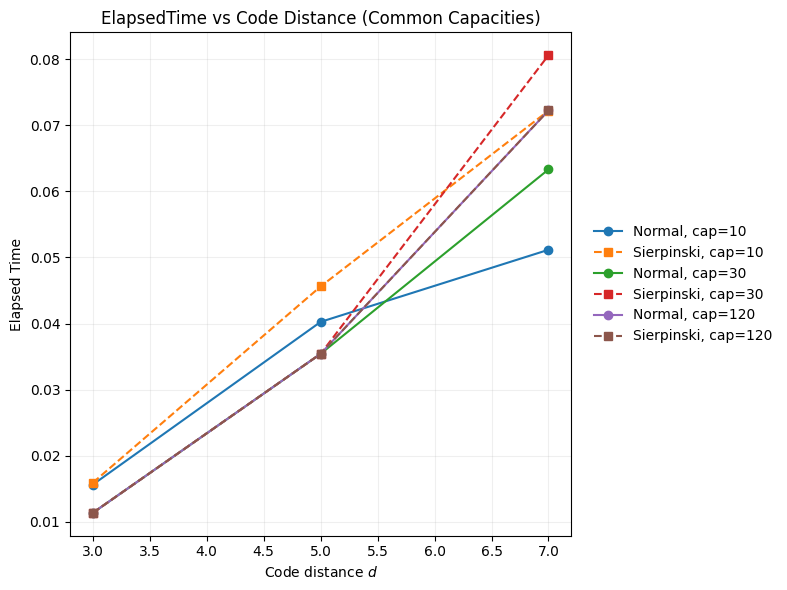

In [7]:
# want to plot difference between normal + sierpinski mapping (vectorised) - ElapsedTime - plot only common capacities

cc_data_path = r".\data\new_data\cc_halving4326.json"
cc_tri_data_path = r".\data\new_data\cc_triangular4326.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['ElapsedTime'][label]
ops_tri_dict = raw_tri_data['ElapsedTime'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

common_caps = sorted(
    set(df['capacity']).intersection(df_tri['capacity'])
)

print("Common capacities:", common_caps)
df_common = df[df['capacity'].isin(common_caps)].copy()
df_tri_common = df_tri[df_tri['capacity'].isin(common_caps)].copy()

df_common['experiment'] = 'Normal'
df_tri_common['experiment'] = 'Sierpinski'
df_all = pd.concat([df_common, df_tri_common], ignore_index=True)
df_all = df_all[df_all['capacity']>=10]
print(df_all[df_all['capacity']==5])
plt.figure(figsize=(8, 6))

linestyles = {'Normal': '-', 'Sierpinski': '--'}
markers = {'Normal': 'o', 'Sierpinski': 's'}

for (capacity, experiment), subset in df_all.groupby(['capacity', 'experiment']):
    subset = subset.sort_values('d')

    plt.plot(
        subset['d'],
        subset['op_num'],
        linestyle=linestyles[experiment],
        marker=markers[experiment],
        label=f'{experiment}, cap={capacity}'
    )

plt.xlabel('Code distance $d$')
plt.ylabel('Elapsed Time')
#plt.yscale('log')
plt.title('ElapsedTime vs Code Distance (Common Capacities)')
plt.grid(True, which='both', alpha=0.2)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.show()


   d  capacity    op_num    shots experiment
0  3         9  1.393235  1000000     Normal
1  3         8  1.867769  1000000     Normal
2  3        13  1.000000  1000000     Normal
3  3        11  1.000000  1000000     Normal
4  3        12  1.000000  1000000     Normal
   d  capacity    op_num    shots  experiment
0  3         6  2.013423  1000000  Sierpinski
1  3         8  1.831557  1000000  Sierpinski
2  3        12  1.000000  1000000  Sierpinski
3  3        10  1.831557  1000000  Sierpinski
4  3        13  1.000000  1000000  Sierpinski


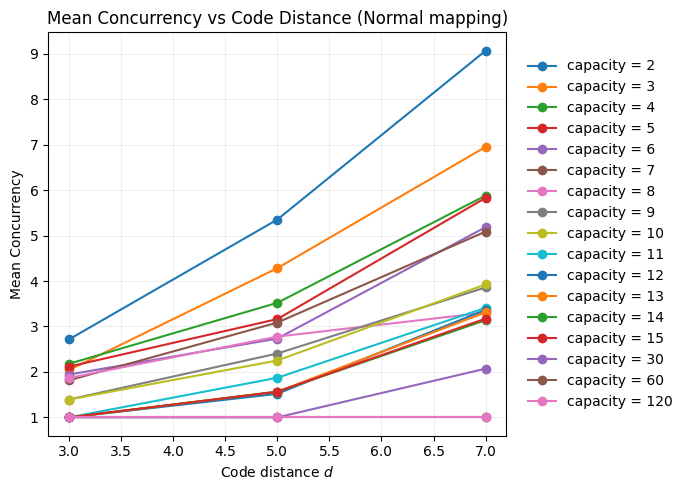

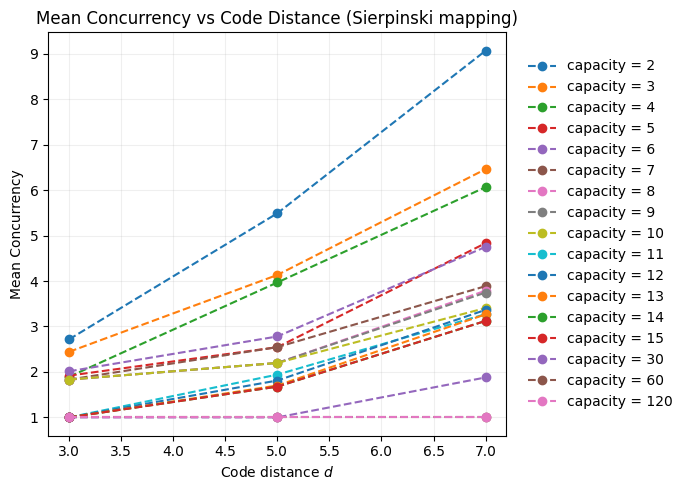

In [10]:
# want to plot difference between normal + sierpinski mapping - Mean Concurrency

cc_data_path = r".\data\new_data\cc_internal_666_half.json"
cc_tri_data_path = r".\data\new_data\cc_internal_666_sierp.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['MeanConcurrency'][label]
ops_tri_dict = raw_tri_data['MeanConcurrency'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)
df['experiment'] = 'Normal'
df_tri['experiment'] = 'Sierpinski'
df_all = pd.concat([df, df_tri], ignore_index=True)

print(df.head())
print(df_tri.head())

linestyles = {'Normal':'-', 'Sierpinski':'--'}

for experiment in ['Normal', 'Sierpinski']:
    plt.figure(figsize=(7, 5))
    data = df_all[df_all['experiment'] == experiment]

    for i, capacity in enumerate(sorted(data['capacity'].unique())):
        subset = data[data['capacity'] == capacity].sort_values('d')

        plt.plot(
            subset['d'],
            subset['op_num'],
            linestyle=linestyles[experiment],
            marker='o',
            label=f'capacity = {capacity}'
        )

    plt.xlabel('Code distance $d$')
    plt.ylabel('Mean Concurrency')
    #plt.yscale('log')
    plt.title(f'Mean Concurrency vs Code Distance ({experiment} mapping)')
    plt.grid(True, which='both', alpha=0.2)
    plt.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )
    plt.tight_layout()
    plt.show()



Common capacities: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 30, 60, 120]
    d  capacity    op_num    shots  experiment
7   3         5  2.116761  1000000      Normal
25  5         5  3.161951  1000000      Normal
34  7         5  5.830011  1000000      Normal
58  3         5  1.918149  1000000  Sierpinski
76  5         5  2.543860  1000000  Sierpinski
87  7         5  4.832926  1000000  Sierpinski


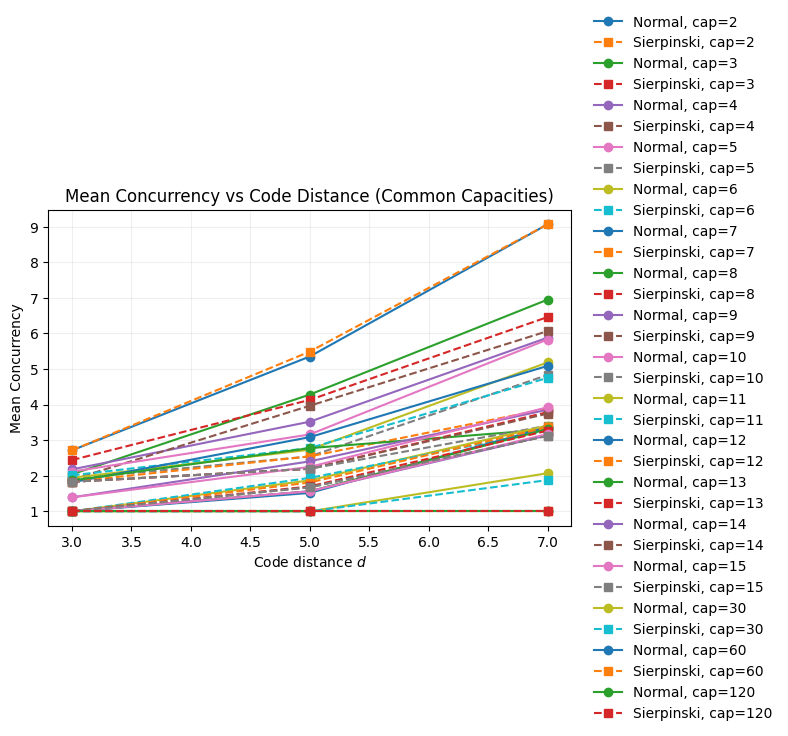

In [11]:
# want to plot difference between normal + sierpinski mapping - MeanConcurrency - plot only common capacities

cc_data_path = r".\data\new_data\cc_internal_666_half.json"
cc_tri_data_path = r".\data\new_data\cc_internal_666_sierp.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['MeanConcurrency'][label]
ops_tri_dict = raw_tri_data['MeanConcurrency'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

common_caps = sorted(
    set(df['capacity']).intersection(df_tri['capacity'])
)

print("Common capacities:", common_caps)
df_common = df[df['capacity'].isin(common_caps)].copy()
df_tri_common = df_tri[df_tri['capacity'].isin(common_caps)].copy()

df_common['experiment'] = 'Normal'
df_tri_common['experiment'] = 'Sierpinski'
df_all = pd.concat([df_common, df_tri_common], ignore_index=True)

print(df_all[df_all['capacity']==5])
plt.figure(figsize=(8, 6))

linestyles = {'Normal': '-', 'Sierpinski': '--'}
markers = {'Normal': 'o', 'Sierpinski': 's'}

for (capacity, experiment), subset in df_all.groupby(['capacity', 'experiment']):
    subset = subset.sort_values('d')

    plt.plot(
        subset['d'],
        subset['op_num'],
        linestyle=linestyles[experiment],
        marker=markers[experiment],
        label=f'{experiment}, cap={capacity}'
    )

plt.xlabel('Code distance $d$')
plt.ylabel('Mean Concurrency')
#plt.yscale('log')
plt.title('Mean Concurrency vs Code Distance (Common Capacities)')
plt.grid(True, which='both', alpha=0.2)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.show()


Common capacities: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 30, 60, 120]
Average proportional difference: -0.15%
Average absolute proportional difference: 6.89%
    d  capacity    op_num    shots  experiment
4   3         5  2.116761  1000000      Normal
25  5         5  3.161951  1000000      Normal
34  7         5  5.830011  1000000      Normal
59  3         5  1.918149  1000000  Sierpinski
75  5         5  2.543860  1000000  Sierpinski
88  7         5  4.832926  1000000  Sierpinski


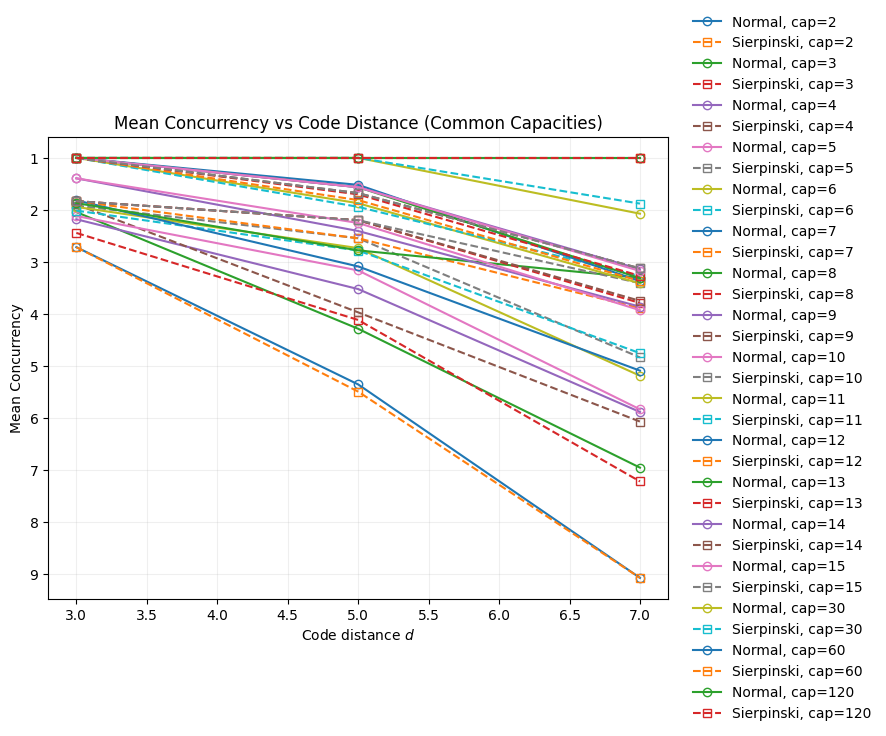

In [11]:
# MEAN CONCURRENCY

cc_data_path = r".\data\cc_halving9326.json"
cc_tri_data_path = r".\data\cc_triangular_vec9326.json"

with open(cc_data_path, 'r') as f:
    raw_data = json.load(f)

with open(cc_tri_data_path,'r') as f:
    raw_tri_data = json.load(f)

records = []
records_tri = []

# Assuming 'Forwarding' is your algorithm name based on your print output
label = 'Forwarding' 

# We need to extract these dictionaries from the raw JSON
# Depending on how your JSON is saved, keys might be inverted. 
# Based on your print(df) output, it looks like: data[Metric][Algorithm][d][capacity]
# Let's try to grab the dictionaries directly.

# Adjust these keys if your JSON nesting order is slightly different
ops_dict = raw_data['MeanConcurrency'][label]
ops_tri_dict = raw_tri_data['MeanConcurrency'][label]

# Iterate through the nested structure
for d_str, cap_dict in ops_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

for d_str, cap_dict in ops_tri_dict.items():
    d = int(d_str)
    for cap_str, op_num in cap_dict.items():
        capacity = int(cap_str)
        records_tri.append({
            'd': d,
            'capacity': capacity,
            'op_num': op_num,
            'shots': 1000000 
        })

# Create the clean, flat DataFrame
df = pd.DataFrame(records)
df_tri = pd.DataFrame(records_tri)

common_caps = sorted(
    set(df['capacity']).intersection(df_tri['capacity'])
)

print("Common capacities:", common_caps)
df_common = df[df['capacity'].isin(common_caps)].copy()
df_tri_common = df_tri[df_tri['capacity'].isin(common_caps)].copy()

df_common['experiment'] = 'Normal'
df_tri_common['experiment'] = 'Sierpinski'

# 1. Merge aligning strictly by 'd' and 'capacity'
df_merged = pd.merge(
    df_common, 
    df_tri_common, 
    on=['d', 'capacity'], 
    suffixes=('_norm', '_tri')
)

# 2. Calculate the proportional difference for each pair
df_merged['prop_diff'] = (df_merged['op_num_tri'] - df_merged['op_num_norm']) / df_merged['op_num_norm']

# 3. Get the average metric
avg_prop_diff = df_merged['prop_diff'].mean()

# Absolute proportional difference (if you just care about magnitude, not direction)
avg_abs_prop_diff = df_merged['prop_diff'].abs().mean()

print(f"Average proportional difference: {avg_prop_diff * 100:.2f}%")
print(f"Average absolute proportional difference: {avg_abs_prop_diff * 100:.2f}%")

df_all = pd.concat([df_common, df_tri_common], ignore_index=True)

print(df_all[df_all['capacity']==5])
plt.figure(figsize=(8, 6))

linestyles = {'Normal': '-', 'Sierpinski': '--'}
markers = {'Normal': 'o', 'Sierpinski': 's'}

for (capacity, experiment), subset in df_all.groupby(['capacity', 'experiment']):
    subset = subset.sort_values('d')

    plt.plot(
        subset['d'],
        subset['op_num'],
        linestyle=linestyles[experiment],
        marker=markers[experiment],
        markerfacecolor='none',  # Makes the markers hollow!
        label=f'{experiment}, cap={capacity}'
    )

plt.xlabel('Code distance $d$')
plt.ylabel('Mean Concurrency')

# Invert the y-axis!
plt.gca().invert_yaxis()

#plt.yscale('log') # (Note: log scales also work perfectly fine when inverted)
plt.title('Mean Concurrency vs Code Distance (Common Capacities)')
plt.grid(True, which='both', alpha=0.2)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
#plt.tight_layout()
plt.show()
